In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

## Import raw emissions data

In this section, we read in the MRR files from 2013-2024 with data about regulated entities' total emissions, emissions breakdown by gas (for 2020 onward), and covered emissions for which they have to turn in compliance instruments (allowances or offsets). We clean up the column names and create a `combined_df` with all the relevant data. 

In [2]:
file_config_by_year = {
    "2013": {
        "file": "2013-ghg-emissions-2019-11-04.xlsx",
        "overview": "2013 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "",
        
    },
    "2014": {
        "file": "2014-ghg-emissions-2019-11-04.xlsx",
        "overview": "2014 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "",
    },
    "2015": {
        "file": "2015-ghg-emissions-2019-11-04.xlsx",
        "overview": "2015 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "",
    },
    "2016": {
        "file": "2016-ghg-emissions-2022-11-04.xlsx",
        "overview": "2016 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "",
    },
    "2017": {
        "file": "2017-ghg-emissions-2022-11-04.xlsx",
        "overview": "2017 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "",
    },
    "2018": {
        "file": "2018-ghg-emissions-2022-11-04.xlsx",
        "overview": "2018 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "",
    },
    "2019": {
        "file": "2019-ghg-emissions-2023-11-06.xlsx",
        "overview": "2019 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "",
    },
    "2020": {
        "file": "2020-ghg-emissions-2024-11-15.xlsx",
        "overview": "2020 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "2020 Emissions by GHG",
        "skiprows_ghg": 6,
    },
    "2021": {
        "file": "2021-ghg-emissions-2023-11-06.xlsx",
        "overview": "2021 GHG Data",
        "skiprows_overview": 9,
        "ghgs": "2021 Emissions by GHG",
        "skiprows_ghg": 6,
    },
    "2022": {
        "file": "2022-ghg-emissions_2025_11_04.xlsx",
        "overview": "2022 GHG Data",
        "skiprows_overview": 7,
        "ghgs": "2022 Emissions by GHG",
        "skiprows_ghg": 6,
    },
     "2023": {
        "file": "2023-ghg-emissions_2025_11_04.xlsx",
        "overview": "2023 GHG Data",
        "skiprows_overview": 7,
        "ghgs": "2023 Emissions by GHG",
        "skiprows_ghg": 5,
    },
      "2024": {
        "file": "2024-ghg-emissions-2025-11-04.xlsx",
        "overview": "2024 GHG Data",
        "skiprows_overview": 7,
        "ghgs": "2024 Emissions by GHG",
        "skiprows_ghg": 5,
    },
}

years = [str(y) for y in range(2013, 2025)]

rename_overview = {
    "ARB ID": "facility_id",
    "Report\nYear": "report_year",
    "Facility Name": "facility_name",
    "City": "city",
    "State": "state",
    "Industry Sector": "sector",
    "Total CO2e \n(combustion, process, vented, and supplier)": "total_co2e",
    "Total Covered Emissions": "total_covered_co2e",
    "Total Non-Covered Emissions ": "total_non_coverned_co2e"
}

rename_ghgs = {
    "ARB ID": "facility_id",
    "CO2": "co2",
    " CH4": "ch4",
    "N2O": "n2o"
}

In [3]:
# silence warnings about excel features (e.g. dropdowns) that aren't recognized
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

dfs = []

for year in years: 
    
    # read and clean-up overview data tab
    df_overview = pd.read_excel("input-data/mrr-data/" + file_config_by_year[year]['file'], sheet_name=file_config_by_year[year]['overview'], skiprows=file_config_by_year[year]['skiprows_overview'])
    df_overview = df_overview[rename_overview.keys()].rename(columns=rename_overview)
    
    # read and clean-up ghg data tab, if available
    if file_config_by_year[year]['ghgs']:
        df_ghgs = pd.read_excel("input-data/mrr-data/" + file_config_by_year[year]['file'], sheet_name=file_config_by_year[year]['ghgs'], skiprows=file_config_by_year[year]['skiprows_ghg'])
        df_ghgs = df_ghgs[rename_ghgs.keys()].rename(columns=rename_ghgs)
    else:
        df_ghgs = pd.DataFrame(columns=rename_ghgs.values())
    
    # combine the two tabs of data and add to df list
    merged_df = pd.merge(df_overview, df_ghgs, on='facility_id', how='left')
    dfs.append(merged_df)

combined_df = pd.concat(dfs, ignore_index=True)

In [4]:
combined_df

,facility_id,report_year,facility_name,city,state,sector,total_co2e,total_covered_co2e,total_non_coverned_co2e,co2,ch4,n2o
0,3006,2013,3 Phases Renewables,El Segundo,CA,Electricity Importer,5656.071360,3779.719360,1876.352000,NaN,NaN,NaN
1,104356,2013,3M Corona,Corona,CA,Other Combustion Source,13093.829450,0.000000,13093.829450,NaN,NaN,NaN
2,104213,2013,ABI Foundry,Oakland,CA,Other Combustion Source,13925.107092,0.000000,13925.107092,NaN,NaN,NaN
3,100001,2013,ACE Cogeneration,Trona,CA,Cogeneration,325824.102748,325824.102748,0.000000,NaN,NaN,NaN
4,104347,2013,"Aemetis Advanced Fuels Keyes, Inc.",Ceres,CA,Other Combustion Source,55566.444525,55566.444525,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
9823,104678,2024,WP&A King,Lost Hills,CA,Other Combustion Source,9885.811805,0.000000,9886.000000,9876.679169,0.166654,0.016665
9824,101736,2024,WP&A Lost Hills,Lost Hills,CA,Other Combustion Source,42625.088930,42625.000000,0.000000,42583.249204,0.763499,0.076350
9825,104618,2024,"WWF Operating Company, LLC",City of Industry,CA,Other Combustion Source,17463.933880,0.000000,17464.000000,17445.902276,0.329044,0.032904
9826,100322,2024,Yuba City Cogeneration Partners LP,Yuba City,CA,Cogeneration,11597.061410,11597.000000,0.000000,11585.087382,0.218504,0.021850


## Test understanding of the data

In this section, we test our understanding of the raw data. Specifically, for the years where both total emissions (CO2e) and gas specific emissions are reported, do the GWP converted values match? And for all years, is the sum of covered and uncovered emissions match the reported total emissions? 

Learnings: 
- GWP values switched in 2021. Converting between gas specific emissions and total emissions must happen with those year-specific values. 
- There are many small differences (<1 tCO2e) between total emissions and covered+uncovered. The only substantial differences are in 2021. Still getting to the bottom of those... 

In [5]:
# the published mrr data (2021 onward) includes the following documentation in the `column description` tab: 
# The CO2e totals shown, which include emissions from carbon dioxide (CO2), methane (CH4), and 
# nitrous oxide (N2O), are multiplied by their respective GWPs of 1, 25, and 298 prior to being 
# added to the totals. The GWPs used are from Title 40, Part 98 of the Code of Federal Regulations,
# Subpart A, Table A-1, as published in the Federal Register on 12/11/2014.

gwp_values_2021_onwards = {
    'co2': 1, 
    'ch4': 25,
    'n2o': 298
}

# the published mrr data (2020 and before) includes the following documentation in the `column description` tab:
# The CO2e totals shown, which include emissions from carbon dioxide (CO2), methane (CH4), and 
# nitrous oxide (N2O), are multiplied by their respective GWPs of 1, 21, and 310 prior to being 
# added to the totals. The GWPs used are from Title 40, Part 98 of the Code of Federal Regulations, 
# Subpart A, Table A-1, as published in the Federal Register on October 30, 2009 
# (http://www.arb.ca.gov/cc/reporting/ghg-rep/regulation/subpart a rule part98.pdf)

gwp_values_2020_prior = {
    'co2': 1, 
    'ch4': 21,
    'n2o': 310
}

In [6]:
# calculate difference between the sum of the the individual gas columns * gwp values and total emissions (co2e)
# when using year-dependent gwp values, there are no differences

differences = (
    combined_df
    .assign(
        difference=lambda x: ((x['total_co2e']) - (
            x['co2'] + 
            x['ch4'] * x['report_year'].apply(lambda y: gwp_values_2020_prior["ch4"] if y <= 2020 else gwp_values_2021_onwards["ch4"]) + 
            x['n2o'] * x['report_year'].apply(lambda y: gwp_values_2020_prior["n2o"] if y <= 2020 else gwp_values_2021_onwards["n2o"])
        )).round(2)
    )
)[['facility_id', 'report_year', 'total_co2e', 'co2', 'ch4', 'n2o', 'difference']]

differences[differences['difference'] > 0].groupby('report_year')['facility_id'].count()

Series([], Name: facility_id, dtype: int64)

In [7]:
# calculate difference between the sum of covered+uncovered and the total emissions

total_differences = (
    combined_df
    .assign(
        difference=lambda x: ((x['total_covered_co2e'] + x['total_non_coverned_co2e']) - 
                             (x['total_co2e'])).round(2)
    )
)[['facility_id', 'report_year', 'total_co2e', 'total_covered_co2e', 'total_non_coverned_co2e', 'difference']]

total_differences[total_differences['difference'] > 1].groupby('report_year')['facility_id'].count()

report_year
2021    2
Name: facility_id, dtype: int64

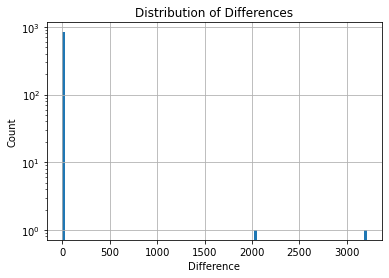

,facility_id,report_year,total_co2e,total_covered_co2e,total_non_coverned_co2e,difference
6890,104099,2021,47712.163216,50922.0,0.0,3209.84
7166,3081,2021,279519.369415,281568.0,0.0,2048.63
7156,104081,2021,653570.955375,645407.0,8163.0,-0.96
6589,100002,2021,285809.907123,285809.0,0.0,-0.91
6926,101331,2021,19262.134981,18795.0,468.0,0.87


In [8]:
year = 2021

total_differences[total_differences['report_year'] == year]['difference'].hist(bins=100, log=True)
plt.xlabel('Difference')
plt.ylabel('Count')
plt.title('Distribution of Differences')
plt.show()

total_differences.reindex(total_differences[total_differences['report_year'] == year]['difference'].abs().sort_values(ascending=False).index).head(5)

^ As of 4/6, the only weirdness in comparing total emissions to covered+uncovered seems to be in the 2021 data. Both facilities are electricity importers where the `electricity importer covered emissions` > `electricity importer co2e`.

## Create covered emissions timeseries

To create a gas-specific timeseries of covered emissions, we have to reckon with the fact that gas-specific emissions are only reported from 2020 onward. And even in those years, it's a breakdown of total emissions rather than covered emissions. 

Method: 
- From 2020-2024: assume that each report gas contributes proportionally to covered emissions. 
- From 2013-2021: use the average proportion of covered gases (2020-2024) for each facility to estimate gas-specific covered emissions; if a facility does not have gas specific data in any year, assume all emissions are co2

Potential problems: 
- A facility's fuel mix or process could have changed between 2013-2019 and 2020-2024, making the backcast inaccurate. 
- Facilities' emissions mix doesn't seem _that_ stable from year to year in 2020-2024. Is an average reasonable?
- Covid funkiness? 

TODO: update this when questions about 2020 data (dug up above) are resolved w/ CARB

In [21]:
df = combined_df[combined_df['total_covered_co2e'] != 0].copy()
mask = df[['co2', 'ch4', 'n2o']].isna().all(axis=1)

# where we have ghg specific data, scale each gas's emissions by the ratio of covered emissions to total emissions
df['covered_ratio'] = df['total_covered_co2e'] / df['total_co2e']
df.loc[~mask, 'covered_co2'] = df.loc[~mask, 'co2'] * df.loc[~mask, 'covered_ratio']
df.loc[~mask, 'covered_ch4'] = df.loc[~mask, 'ch4'] * df.loc[~mask, 'covered_ratio']
df.loc[~mask, 'covered_n2o'] = df.loc[~mask, 'n2o'] * df.loc[~mask, 'covered_ratio']

In [22]:
# expect to see covered gas specific numbers only for 2020 onwards for a specific facility
test_fid = 104392
df[df['facility_id'] == test_fid]

,facility_id,report_year,facility_name,city,state,sector,total_co2e,total_covered_co2e,total_non_coverned_co2e,co2,ch4,n2o,covered_ratio,covered_co2,covered_ch4,covered_n2o
1583,104392,2014,Wild Goose Storage LLC,Grildey,CA,Oil and Gas Production,42902.717790,41826.587790,1076.13000,NaN,NaN,NaN,0.974917,NaN,NaN,NaN
2396,104392,2015,Wild Goose Storage LLC,Grildey,CA,Oil and Gas Production,21617.973728,20862.181728,755.79200,NaN,NaN,NaN,0.965039,NaN,NaN,NaN
3201,104392,2016,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,14656.938436,13610.844436,1046.09400,NaN,NaN,NaN,0.928628,NaN,NaN,NaN
3963,104392,2017,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,20631.601057,19775.349987,856.25107,NaN,NaN,NaN,0.958498,NaN,NaN,NaN
4834,104392,2018,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,28810.130424,27205.486424,1604.64400,NaN,NaN,NaN,0.944303,NaN,NaN,NaN
5651,104392,2019,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,41661.885559,40995.000000,666.00000,NaN,NaN,NaN,0.983993,NaN,NaN,NaN
6488,104392,2020,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,33435.118287,32424.000000,1011.00000,24001.489301,448.552481,0.045248,0.969759,23275.655328,434.987713,0.043880
7323,104392,2021,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,30731.360032,29914.000000,817.00000,23853.213006,274.589763,0.044976,0.973403,23218.790614,267.286517,0.043780
8157,104392,2022,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,32252.189055,31875.000000,377.00000,29226.734146,120.361184,0.055118,0.988305,28884.927758,118.953562,0.054474
8995,104392,2023,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,44444.136620,43484.000000,960.00000,41426.822395,119.761281,0.078128,0.978397,40531.869489,117.174052,0.076440


In [23]:
# calculate average gas proportion for each facility that reports separate emissions (2020-2024)
# for this, we need to use year-specific gwp values because that will affect the "weight" they have
# in relation to total covered emissions. 

df['gwp_ch4'] = df['report_year'].apply(lambda y: gwp_values_2020_prior['ch4'] if y <= 2020 else gwp_values_2021_onwards['ch4'])
df['gwp_n2o'] = df['report_year'].apply(lambda y: gwp_values_2020_prior['n2o'] if y <= 2020 else gwp_values_2021_onwards['n2o'])

gas_proportions = (
    df[~mask]
    .groupby('facility_id')
    .apply(lambda x: pd.Series({
        'co2_proportion': (x['covered_co2'] / (x['covered_co2'] + (x['covered_ch4'] * x['gwp_ch4']) + (x['covered_n2o'] * x['gwp_n2o']))).mean(),
        'ch4_proportion': ((x['covered_ch4'] * x['gwp_ch4']) / (x['covered_co2'] + (x['covered_ch4'] * x['gwp_ch4']) + (x['covered_n2o'] * x['gwp_n2o']))).mean(),
        'n2o_proportion': ((x['covered_n2o'] * x['gwp_n2o']) / (x['covered_co2'] + (x['covered_ch4'] * x['gwp_ch4']) + (x['covered_n2o'] * x['gwp_n2o']))).mean(),
    }))
    .reset_index()
)

# apply calculated proportion to years without gas-specific data; if facility never has gas ratios reported, assume 
# all covered emissions are co2. 
df.loc[mask, 'covered_co2'] = df.loc[mask, 'total_covered_co2e'] * df.loc[mask, 'facility_id'].map(gas_proportions.set_index('facility_id')['co2_proportion']).fillna(1)
df.loc[mask, 'covered_ch4'] = (df.loc[mask, 'total_covered_co2e'] * df.loc[mask, 'facility_id'].map(gas_proportions.set_index('facility_id')['ch4_proportion']).fillna(0)) / df.loc[mask, 'gwp_ch4']
df.loc[mask, 'covered_n2o'] = (df.loc[mask, 'total_covered_co2e'] * df.loc[mask, 'facility_id'].map(gas_proportions.set_index('facility_id')['n2o_proportion']).fillna(0)) / df.loc[mask, 'gwp_n2o']

In [24]:
# expect to see covered gas-specific numbers for before 2020 
df[df['facility_id'] == test_fid]

,facility_id,report_year,facility_name,city,state,sector,total_co2e,total_covered_co2e,total_non_coverned_co2e,co2,ch4,n2o,covered_ratio,covered_co2,covered_ch4,covered_n2o,gwp_ch4,gwp_n2o
1583,104392,2014,Wild Goose Storage LLC,Grildey,CA,Oil and Gas Production,42902.717790,41826.587790,1076.13000,NaN,NaN,NaN,0.974917,35064.427334,321.062891,0.063999,21,310
2396,104392,2015,Wild Goose Storage LLC,Grildey,CA,Oil and Gas Production,21617.973728,20862.181728,755.79200,NaN,NaN,NaN,0.965039,17489.364872,160.139106,0.031921,21,310
3201,104392,2016,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,14656.938436,13610.844436,1046.09400,NaN,NaN,NaN,0.928628,11410.360991,104.477494,0.020826,21,310
3963,104392,2017,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,20631.601057,19775.349987,856.25107,NaN,NaN,NaN,0.958498,16578.242674,151.796533,0.030258,21,310
4834,104392,2018,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,28810.130424,27205.486424,1604.64400,NaN,NaN,NaN,0.944303,22807.139004,208.830616,0.041627,21,310
5651,104392,2019,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,41661.885559,40995.000000,666.00000,NaN,NaN,NaN,0.983993,34367.283455,314.679583,0.062727,21,310
6488,104392,2020,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,33435.118287,32424.000000,1011.00000,24001.489301,448.552481,0.045248,0.969759,23275.655328,434.987713,0.043880,21,310
7323,104392,2021,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,30731.360032,29914.000000,817.00000,23853.213006,274.589763,0.044976,0.973403,23218.790614,267.286517,0.043780,25,298
8157,104392,2022,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,32252.189055,31875.000000,377.00000,29226.734146,120.361184,0.055118,0.988305,28884.927758,118.953562,0.054474,25,298
8995,104392,2023,Wild Goose Storage LLC,Gridley,CA,Oil and Gas Production,44444.136620,43484.000000,960.00000,41426.822395,119.761281,0.078128,0.978397,40531.869489,117.174052,0.076440,25,298


In [25]:
timeseries_covered_emissions = df.groupby('report_year')[['total_covered_co2e', 'covered_co2', 'covered_ch4', 'covered_n2o']].sum().reset_index()
timeseries_covered_emissions

,report_year,total_covered_co2e,covered_co2,covered_ch4,covered_n2o
0,2013,3.485027e+08,3.456671e+08,27976.346403,7252.025424
1,2014,3.429444e+08,3.400368e+08,29419.607780,7386.508384
2,2015,3.404268e+08,3.374770e+08,30077.178879,7477.866051
3,2016,3.240659e+08,3.211463e+08,27774.388602,7536.665293
4,2017,3.205834e+08,3.176588e+08,27313.851209,7583.853015
5,2018,3.199015e+08,3.170013e+08,27299.772333,7506.298706
6,2019,3.111641e+08,3.083560e+08,26594.212897,7256.789170
7,2020,2.786042e+08,2.762526e+08,19188.685974,6285.808443
8,2021,2.922188e+08,2.897548e+08,18043.906728,6754.850466
9,2022,2.816514e+08,2.792486e+08,18213.108276,6535.328700


In [26]:
# TODO: what kind of validation could we do on this timeseries? any events in the cap and trade program that we'd expect to 

In [27]:
# save timeseries as a csv 
timeseries_covered_emissions.to_csv('output-data/timeseries_covered_emissions.csv', index=False)

## Create offset emissions timeseries

Not all covered emissions are compensated for with offsets. The majority are associated with state-issued allowanced — and the maximum use of offsets has ranged from 4-8% over course of the program. 

Method: 
- Using the compliance summary reports, calculate what proportion of total covered emissions were compensated for using offsets on a yearly basis. 
- Use that ratio to estimate the proportion of gas-specific emissions that we should associate with offset use on a yearly basis. 

Problems: 
- Do regulated entities ever turn in more compliance instruments than their covered emissions?
- 2024 is probably anomolously low given it doesn't reflect data from a full compliance period. Consider dropping?

In [28]:
compliance_config_by_year = {
    "2014": {
        "file": "2013-2014compliancereport.xlsx",
        "compliance_summary": "2013-2014 Compliance Summary",
        "skiprows": 4    
    },
    "2017": {
        "file": "2015-2017compliancereport.xlsx",
        "compliance_summary": "2015-2017 Compliance Summary",
        "skiprows": 4
    },
    "2020": {
        "file": "nc-2018-2020compliancereport.xlsx",
        "compliance_summary": "2018-2020 Compliance Summary",
        "skiprows": 4
    },
    "2023": {
        "file": "nc-CP4compliancereport.xlsx",
        "compliance_summary": "CP4 Compliance Summary",
        "skiprows": 4
    },
    "2024": {
        "file": "nc-2024compliancereport.xlsx",
        "compliance_summary": "2024 Compliance Summary",
        "skiprows": 4
    },
}

year_to_report = { 
    "2013": "2014",
    "2014": "2014",
    "2015": "2017",
    "2016": "2017",
    "2017": "2017",
    "2018": "2020",
    "2019": "2020",
    "2020": "2020",
    "2021": "2023",
    "2022": "2023",
    "2023": "2023",
    "2024": "2024",
}

rename_compliance_summary = {
        "Total Offsets Surrendered": "offsets_surrendered",
        "Total Instruments Surrendered": "instruments_surrendered",
    }

In [29]:
dfs = []
for report_year, config in compliance_config_by_year.items():
    
    # import raw compliance report data
    df = pd.read_excel( "input-data/compliance-reports/" + config['file'], sheet_name=config['compliance_summary'], skiprows=config['skiprows'])
    df.columns = df.columns.str.strip()
    df = df[rename_compliance_summary.keys()].rename(columns=rename_compliance_summary)
    
    # aggregate values across all entities to calculate the ratio of offsets used
    df['offsets_surrendered'] = pd.to_numeric(df['offsets_surrendered'], errors='coerce')
    df['instruments_surrendered'] = pd.to_numeric(df['instruments_surrendered'], errors='coerce')
    total_offsets = df['offsets_surrendered'].sum()
    total_instruments = df['instruments_surrendered'].sum()
    offset_ratio = total_offsets / total_instruments
    
    dfs.append({'report_year': report_year, 'offset_ratio': offset_ratio})

offset_ratios = pd.DataFrame(dfs)

# map ratio to each individual year
offset_ratios = (
    pd.DataFrame(list(year_to_report.items()), columns=['year', 'report_year'])
    .merge(offset_ratios, on='report_year', how='left')
    .drop(columns='report_year')
)

In [30]:
# would expect <8% from 2013-2020, <4% from 2021-2025 
# see: https://ww2.arb.ca.gov/sites/default/files/cap-and-trade/public_info.pdf
offset_ratios

,year,offset_ratio
0,2013,0.040857
1,2014,0.040857
2,2015,0.063852
3,2016,0.063852
4,2017,0.063852
5,2018,0.069445
6,2019,0.069445
7,2020,0.069445
8,2021,0.030886
9,2022,0.030886


In [31]:
# we can use the offset ratios to calculate what portion of "covered emissions" are justified by offsets, 
# rather than allowances

timeseries_covered_emissions['report_year'] = timeseries_covered_emissions['report_year'].astype(int)
offset_ratios['year'] = offset_ratios['year'].astype(int)

timeseries_emission_fluxes = timeseries_covered_emissions.merge(
    offset_ratios,
    left_on='report_year',
    right_on='year',
    how='left'
)
timeseries_emission_fluxes = timeseries_emission_fluxes.drop(columns='year')

timeseries_emission_fluxes['co2_flux'] = timeseries_emission_fluxes['covered_co2'] * timeseries_emission_fluxes['offset_ratio']
timeseries_emission_fluxes['ch4_flux'] = timeseries_emission_fluxes['covered_ch4'] * timeseries_emission_fluxes['offset_ratio']
timeseries_emission_fluxes['n2o_flux'] = timeseries_emission_fluxes['covered_n2o'] * timeseries_emission_fluxes['offset_ratio']

timeseries_emission_fluxes = timeseries_emission_fluxes[['report_year','co2_flux', 'ch4_flux', 'n2o_flux']].rename(columns={'report_year': 'year'})
timeseries_emission_fluxes

,year,co2_flux,ch4_flux,n2o_flux
0,2013,1.412276e+07,1143.016575,296.292630
1,2014,1.389272e+07,1201.983233,301.787138
2,2015,2.154862e+07,1920.491316,477.477521
3,2016,2.050587e+07,1773.453299,481.231977
4,2017,2.028319e+07,1744.047015,484.245012
5,2018,2.201402e+07,1895.821250,521.271768
6,2019,2.141365e+07,1846.823971,503.944683
7,2020,1.918425e+07,1332.550257,436.515333
8,2021,8.949234e+06,557.295923,208.627249
9,2022,8.624745e+06,562.521805,201.847199


In [32]:
# save timeseries as a csv 
timeseries_emission_fluxes.to_csv('output-data/timeseries_emission_fluxes.csv', index=False)